In [15]:
from langgraph.graph import StateGraph, START, END
from groq import Groq
from typing import TypedDict, List
import os
from dotenv import load_dotenv

In [16]:


# Load variables from .env into environment
load_dotenv()

# Get the key
api_key = os.getenv("API_KEY1")

# Ensure the key exists
if not api_key:
    raise ValueError("❌ API_KEY not found in .env file")


client = Groq(api_key=api_key)



In [36]:
model="llama-3.1-8b-instant"


In [37]:
class SentimentState(TypedDict):
    review:str
    sentiment:str
    positive_response:str
    negative_response:str
    diagnosis:List[str]
    

In [38]:
def find_sentiment(state: SentimentState):
    """Use LLM to classify sentiment"""

    prompt = f"Classify sentiment of this review as Positive or Negative:\n{state['review']}"

    res = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
    )

    sentiment = res.choices[0].message.content.strip().lower()

    return {**state, "sentiment": sentiment}


In [39]:
def run_diagnosis(state: SentimentState):
    """Generate reasons for negative sentiment"""

    prompt = f"Give short bullet reasons why this review is negative:\n{state['review']}"

    res = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
    )

    diagnosis = res.choices[0].message.content.split("\n")

    return {**state, "diagnosis": diagnosis}


def positive_response(state: SentimentState):
    """Reply to positive review"""

    return {
        **state,
        "positive_response": "Thank you for your positive feedback! We're glad you enjoyed it."
    }

In [40]:

def negative_response(state: SentimentState):
    """Reply to negative review"""

    return {
        **state,
        "negative_response": "We're sorry for your experience. We'll work to improve."
    }


In [41]:
def router(state: SentimentState):
    """Route based on sentiment"""
    if "positive" in state["sentiment"]:
        return "positive_response"
    else:
        return "run_diagnosis"

In [42]:
graph = StateGraph(SentimentState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)
graph.add_node("positive_response", positive_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", router)

graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("positive_response", END)
graph.add_edge("negative_response", END)

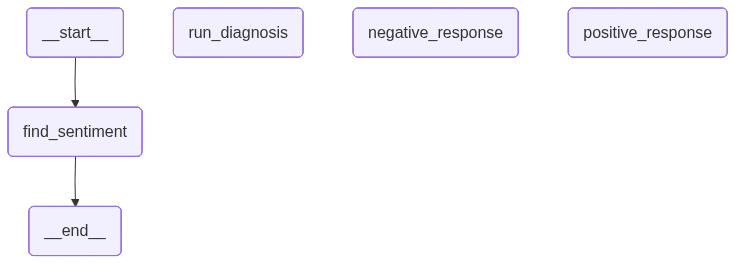

In [43]:
graph.compile()

In [44]:
app = graph.compile()

In [45]:
result = app.invoke({"review": "The product quality was terrible and support was slow."})

print(result)

{'review': 'The product quality was terrible and support was slow.', 'sentiment': 'the sentiment of this review is negative. the reviewer mentions "terrible" product quality and "slow" support, indicating dissatisfaction with the product and service.', 'negative_response': "We're sorry for your experience. We'll work to improve.", 'diagnosis': ['Here are short bullet reasons why this review is negative:', '', '* Poor product quality', '* Slow customer support']}
